# onet_pilot_walkthrough_v2

## Perubahan pada versi v2

Perubahan dari v1: menambahkan penjelasan pemula, glosarium istilah O*NET, rumus normalisasi Importance, arti setiap metode, dan cara membaca output.

Kode dan hasil pada versi ini mengikuti tujuan pilot yang sama.

# O*NET 31.0 Competency Similarity — Notebook Belajar

Notebook ini dibuat untuk membantu memahami apa yang sedang dikerjakan, bukan hanya untuk menjalankan kode. Setiap bagian menjelaskan: **apa yang dilakukan, arti data/kolomnya, dan cara membaca hasilnya**.

Pertanyaan besarnya adalah: **seberapa mirip profil kompetensi berbagai occupation di Amerika Serikat menurut data O*NET?**

## Kamus istilah paling penting

| Istilah | Arti sederhana |
|---|---|
| **Occupation** | Jenis pekerjaan dalam sistem O*NET, misalnya Data Scientists. |
| **O*NET-SOC Code** | Kode unik untuk membedakan occupation. Contoh: 15-2051.00. |
| **Domain** | Kelompok kompetensi: Essential Skills, Transferable Skills, atau Knowledge. |
| **Element ID** | Kode unik untuk satu elemen kompetensi dalam Content Model. Contoh 2.A.1.a adalah Reading Comprehension. |
| **Element Name** | Nama manusiawi dari elemen kompetensi. |
| **Description** | Penjelasan tentang kemampuan/pengetahuan yang dimaksud elemen tersebut. |
| **Scale ID** | Jenis skala angka. IM berarti Importance; LV berarti Level. |
| **Data Value** | Nilai rating asli dari O*NET. |
| **Importance** | Seberapa penting elemen kompetensi untuk occupation tersebut. |
| **Not Relevant** | Elemen dianggap tidak relevan untuk occupation tertentu. |
| **Recommend Suppress** | O*NET merekomendasikan rating tidak ditampilkan/dipakai karena presisinya rendah. |
| **Weight** | Importance yang sudah dinormalisasi menjadi 0 sampai 1. |
| **Similarity** | Ukuran kemiripan dua profil occupation, bukan peluang kerja seseorang. |

## 1. Persiapan

Kita membaca data lokal yang sebelumnya sudah ditempatkan di **data/raw/**. Notebook ini tidak mengunduh apa pun. Model embedding juga dipaksa memakai cache lokal.

In [1]:
from pathlib import Path
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ['HF_HUB_OFFLINE'] = '1'

from src.pipeline_v2 import DOMAINS, EXPECTED, prepare, matrices, similarity, embedding_similarity, validate, related_metrics

RAW = ROOT / 'data' / 'raw'
CONFIG = json.loads((ROOT / 'config' / 'occupations.json').read_text(encoding='utf-8'))
FOCUS = CONFIG['core'] + CONFIG['sensitivity']
print('Folder proyek:', ROOT)
print('Jumlah occupation fokus:', len(FOCUS))

Folder proyek: e:\skripsi
Jumlah occupation fokus: 8


## 2. Memahami tujuh file data

Tiga file rating adalah bahan utama untuk similarity. Empat file lain membantu memberi nama, memeriksa skala, mengenali occupation, dan menyediakan referensi Related Occupations.

In [2]:
ratings = {domain: pd.read_csv(RAW / filename) for domain, filename in DOMAINS.items()}
occupations = pd.read_csv(RAW / 'occupation_data.csv')
content = pd.read_csv(RAW / 'content_model_reference.csv')
related = pd.read_csv(RAW / 'related_occupations.csv')

summary = pd.DataFrame([
    {'file/domain': domain, 'rows': len(df), 'columns': len(df.columns), 'meaning': 'rating kompetensi'}
    for domain, df in ratings.items()
] + [
    {'file/domain': 'occupation_data', 'rows': len(occupations), 'columns': len(occupations.columns), 'meaning': 'daftar occupation'},
    {'file/domain': 'content_model_reference', 'rows': len(content), 'columns': len(content.columns), 'meaning': 'nama dan deskripsi Element ID'},
    {'file/domain': 'related_occupations', 'rows': len(related), 'columns': len(related.columns), 'meaning': 'referensi occupation terkait'},
])
display(summary)

,file/domain,rows,columns,meaning
0,essential_skills,18200,15,rating kompetensi
1,transferable_skills,45500,15,rating kompetensi
2,knowledge,60060,15,rating kompetensi
3,occupation_data,1016,3,daftar occupation
4,content_model_reference,3006,3,nama dan deskripsi Element ID
5,related_occupations,18460,6,referensi occupation terkait


### Melihat satu baris rating

Perhatikan hubungan antar kolom: satu baris berarti **satu occupation memiliki satu rating untuk satu Element ID pada satu Scale ID**.

Untuk analisis utama, kita hanya mengambil **Scale ID = IM**. Jadi LV tidak ikut masuk matriks utama.

In [3]:
sample = ratings['essential_skills'].iloc[[0, 1]].T.rename(columns={ratings['essential_skills'].index[0]: 'contoh IM', ratings['essential_skills'].index[1]: 'contoh LV'})
display(sample)
display(Markdown('**Cara membaca:** kedua baris dapat memiliki occupation dan Element ID yang sama, tetapi Scale ID berbeda. IM adalah Importance; LV adalah Level.'))

,contoh IM,contoh LV
O*NET-SOC Code,11-1011.00,11-1011.00
Title,Chief Executives,Chief Executives
Element ID,2.A.1.a,2.A.1.a
Element Name,Reading Comprehension,Reading Comprehension
Scale ID,IM,LV
Scale Name,Importance,Level
Data Value,4.12,4.62
N,8,8
Standard Error,0.125,0.183
Lower CI Bound,3.88,4.2664


**Cara membaca:** kedua baris dapat memiliki occupation dan Element ID yang sama, tetapi Scale ID berbeda. IM adalah Importance; LV adalah Level.

## 3. Memilih data yang layak dibandingkan

Kita memisahkan rating valid dari rating yang tidak boleh dipaksakan menjadi nol.

- **Valid**: Data Value ada, Not Relevant bukan Y, dan Recommend Suppress bukan Y.
- **Missing**: Data Value tidak tersedia.
- **Not Relevant**: kompetensi tidak relevan bagi occupation.
- **Recommend Suppress**: rating sebaiknya ditekan karena presisinya rendah.

Tidak satu pun dari tiga status terakhir dianggap sebagai bobot 0.

In [4]:
codes = occupations['O*NET-SOC Code'].astype(str).tolist()
valid, expected, audit, complete_codes = prepare(ratings, codes)

coverage_summary = pd.DataFrame([
    {'domain': d, 'elemen_wajib': EXPECTED[d], 'sebelum_eksklusi': audit[d]['before_exclusion'], 'eligible_sesudah_eksklusi': audit[d]['eligible_after_exclusion']}
    for d in DOMAINS
])
display(coverage_summary)
display(Markdown(f'**Complete-case utama:** {len(complete_codes)} occupation lolos semua domain.'))

display(pd.DataFrame(audit['occupation']['excluded_from_complete_case']).head(15))

,domain,elemen_wajib,sebelum_eksklusi,eligible_sesudah_eksklusi
0,essential_skills,10,1016,910
1,transferable_skills,25,1016,910
2,knowledge,33,1016,884


**Complete-case utama:** 884 occupation lolos semua domain.

,occupation,failed_domains
0,11-1031.00,"[essential_skills, transferable_skills, knowle..."
1,11-9039.00,"[essential_skills, transferable_skills, knowle..."
2,11-9179.00,"[essential_skills, transferable_skills, knowle..."
3,11-9199.00,"[essential_skills, transferable_skills, knowle..."
4,13-1199.00,"[essential_skills, transferable_skills, knowle..."
5,13-2051.00,"[essential_skills, transferable_skills, knowle..."
6,13-2054.00,"[essential_skills, transferable_skills, knowle..."
7,13-2099.00,"[essential_skills, transferable_skills, knowle..."
8,15-1299.00,"[essential_skills, transferable_skills, knowle..."
9,15-2099.00,"[essential_skills, transferable_skills, knowle..."


## 4. Normalisasi Importance

O*NET IM berada pada skala 1 sampai 5. Kita mengubahnya ke 0 sampai 1 agar mudah dipakai sebagai bobot:

**importance_norm = (Importance − 1) / (5 − 1)**

Contoh: rating 1 menjadi 0, rating 3 menjadi 0,5, dan rating 5 menjadi 1. Missing/Not Relevant/Recommend Suppress tetap NaN atau status invalid.

In [5]:
example = ratings['knowledge'][ratings['knowledge']['Scale ID'].eq('IM')].copy()
example['Data Value'] = pd.to_numeric(example['Data Value'], errors='coerce')
suppress = example['Recommend Suppress'].fillna('').astype(str).str.upper().eq('Y')
irrelevant = example['Not Relevant'].fillna('').astype(str).str.upper().eq('Y')
example['status'] = np.select([example['Data Value'].isna(), irrelevant, suppress], ['missing', 'not_relevant', 'recommend_suppress'], default='valid')
example['importance_norm'] = np.where(example['status'].eq('valid'), (example['Data Value'] - 1) / 4, np.nan)
display(example[['O*NET-SOC Code','Element ID','Scale ID','Data Value','status','importance_norm']].head(12))

,O*NET-SOC Code,Element ID,Scale ID,Data Value,status,importance_norm
0,11-1011.00,2.C.1.a,IM,4.78,valid,0.9450
2,11-1011.00,2.C.1.b,IM,2.42,valid,0.3550
4,11-1011.00,2.C.1.c,IM,4.04,valid,0.7600
6,11-1011.00,2.C.1.d,IM,3.81,valid,0.7025
8,11-1011.00,2.C.1.e,IM,4.39,valid,0.8475
10,11-1011.00,2.C.1.f,IM,4.48,valid,0.8700
12,11-1011.00,2.C.2.a,IM,2.71,valid,0.4275
14,11-1011.00,2.C.2.b,IM,1.14,valid,0.0350
16,11-1011.00,2.C.3.a,IM,3.82,valid,0.7050
18,11-1011.00,2.C.3.b,IM,3.05,valid,0.5125


## 5. Matriks occupation × kompetensi

Matriks adalah tabel besar:

- baris = occupation;
- kolom = Element ID kompetensi;
- isi sel = Importance yang sudah dinormalisasi.

Matriks utama hanya berisi 884 occupation complete-case. Subset pekerjaan bidang data tidak digunakan untuk membatasi perhitungan; subset hanya dipakai saat membaca hasil.

In [6]:
all_matrices = matrices(valid, codes, expected)
main_matrices = {domain: matrix.loc[complete_codes] for domain, matrix in all_matrices.items()}
display(pd.DataFrame([{'domain': d, 'jumlah_occupation': m.shape[0], 'jumlah_element': m.shape[1], 'sel_valid': int(m.notna().sum().sum())} for d,m in main_matrices.items()]))
display(main_matrices['essential_skills'].head())

,domain,jumlah_occupation,jumlah_element,sel_valid
0,essential_skills,884,10,8840
1,transferable_skills,884,25,22100
2,knowledge,884,33,29172


competency,2.A.1.a,2.A.1.b,2.A.1.c,2.A.1.d,2.A.1.e,2.A.1.f,2.A.2.a,2.A.2.b,2.A.2.c,2.A.2.d
O*NET-SOC Code,,,,,,,,,,
11-1011.00,0.7800,0.75,0.7800,0.8125,0.5625,0.1550,0.845,0.6875,0.5300,0.7500
11-1011.03,0.7500,0.75,0.7800,0.7500,0.4700,0.2800,0.780,0.6875,0.5950,0.6875
11-1021.00,0.7500,0.75,0.6250,0.7500,0.4050,0.1250,0.720,0.6550,0.5000,0.7500
11-2011.00,0.6875,0.78,0.6875,0.7800,0.4700,0.1250,0.720,0.5950,0.5000,0.6250
11-2021.00,0.7200,0.78,0.5625,0.7500,0.5000,0.1875,0.720,0.7200,0.5625,0.7200


## 6. Metode pertama: text embedding

Nama dan deskripsi setiap Element ID diubah menjadi vektor angka oleh model bahasa Inggris. Setelah itu, vektor kompetensi digabungkan untuk setiap occupation dengan bobot Importance.

Cosine similarity menjawab: **seberapa mirip arah representasi semantik dua profil occupation?**

Ini bukan berarti model memahami karier atau kecocokan individu. Ia terutama membandingkan makna teks kompetensi.

In [7]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(CONFIG['embedding_model'])
texts = content.set_index('Element ID')['Element Name'].fillna('') + ' ' + content.set_index('Element ID')['Description'].fillna('')

e_embedding = {}
for domain, matrix in main_matrices.items():
    e_embedding[domain] = embedding_similarity(matrix, texts, model)[0]

display(texts.head(8).to_frame('teks_yang_di-embed'))
display(e_embedding['essential_skills'].iloc[:5, :5])

c:\Users\Wiraditya\AppData\Local\Programs\Python\Python314\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


,teks_yang_di-embed
Element ID,
1,Worker Characteristics Personal traits and abi...
1.A,Abilities Natural talents and capabilities tha...
1.A.1,Cognitive Abilities Abilities that influence t...
1.A.1.a,Verbal Abilities Abilities that influence the ...
1.A.1.a.1,Oral Comprehension The ability to listen to an...
1.A.1.a.2,Written Comprehension The ability to read and ...
1.A.1.a.3,Oral Expression The ability to communicate inf...
1.A.1.a.4,Written Expression The ability to communicate ...


,11-1011.00,11-1011.03,11-1021.00,11-2011.00,11-2021.00
11-1011.00,1.000000,0.999273,0.998677,0.999242,0.998148
11-1011.03,0.999273,1.000000,0.998067,0.998681,0.998363
11-1021.00,0.998677,0.998067,1.000000,0.998992,0.998695
11-2011.00,0.999242,0.998681,0.998992,1.000000,0.997959
11-2021.00,0.998148,0.998363,0.998695,0.997959,1.000000


## 7. Metode kedua: skill graph

Graph menghubungkan occupation dengan competency. Jika Data Scientist memiliki Reading Comprehension, ada edge di antara keduanya. Bobot edge adalah importance_norm.

Generalized Jaccard menjawab: **seberapa besar bobot kompetensi yang sama dibandingkan dengan total bobot gabungan?**

Rumusnya: **sum(min(weight A, weight B)) / sum(max(weight A, weight B))**

In [8]:
g_graph = {}
for domain, matrix in main_matrices.items():
    g_graph[domain] = similarity(matrix, 'graph')[0]
display(g_graph['essential_skills'].iloc[:5, :5])

,11-1011.00,11-1011.03,11-1021.00,11-2011.00,11-2021.00
11-1011.00,1.000000,0.926562,0.906426,0.888889,0.898968
11-1011.03,0.926562,1.000000,0.905195,0.896813,0.916228
11-1021.00,0.906426,0.905195,1.000000,0.930036,0.931048
11-2011.00,0.888889,0.896813,0.930036,1.000000,0.911799
11-2021.00,0.898968,0.916228,0.931048,0.911799,1.000000


## 8. Membaca dan memeriksa enam matriks similarity

Ada enam matriks utama:

- graph × Essential Skills, Transferable Skills, Knowledge;
- embedding × Essential Skills, Transferable Skills, Knowledge.

Validator memeriksa empat hal dasar: semua angka finite, matriks simetris, diagonal bernilai 1, dan semua skor berada pada 0 sampai 1. Jika semua True, struktur matriks aman untuk dibaca.

In [9]:
validation_rows = []
for method, collection in [('graph', g_graph), ('embedding', e_embedding)]:
    for domain, matrix in collection.items():
        validation_rows.append({'matrix': method + ' × ' + domain, **validate(method + '_' + domain, matrix)})
display(pd.DataFrame(validation_rows))

,matrix,shape,all_finite,symmetric,diagonal_is_one,bounded_0_1,passed
0,graph × essential_skills,"[884, 884]",True,True,True,True,True
1,graph × transferable_skills,"[884, 884]",True,True,True,True,True
2,graph × knowledge,"[884, 884]",True,True,True,True,True
3,embedding × essential_skills,"[884, 884]",True,True,True,True,True
4,embedding × transferable_skills,"[884, 884]",True,True,True,True,True
5,embedding × knowledge,"[884, 884]",True,True,True,True,True


## 9. Shared competencies dan competency gap

Kita kembali ke Element ID agar hasil dapat dijelaskan dengan bahasa manusia.

- **Shared competency**: elemen yang sama-sama memiliki rating valid pada dua occupation.
- **Shared weight**: nilai minimum dari bobot A dan B.
- **Gap**: bobot A dikurangi bobot B.
- **Gap positif**: elemen lebih penting pada A.
- **Gap negatif**: elemen lebih penting pada B.

Bagian ini dibuat untuk seluruh pasangan occupation fokus.

In [10]:
names = content.set_index('Element ID')['Element Name'].to_dict()
descriptions = content.set_index('Element ID')['Description'].to_dict()
shared, gaps = [], []
for domain, matrix in main_matrices.items():
    selected = [x for x in FOCUS if x in matrix.index]
    for a, b in __import__('itertools').combinations(selected, 2):
        for element in matrix.columns:
            wa, wb = matrix.loc[a, element], matrix.loc[b, element]
            if pd.notna(wa) and pd.notna(wb):
                row = {'domain': domain, 'occupation_a': a, 'occupation_b': b, 'element_id': element, 'element_name': names.get(element,''), 'description': descriptions.get(element,''), 'weight_a': wa, 'weight_b': wb}
                shared.append({**row, 'shared_weight': min(wa, wb)})
                gaps.append({**row, 'signed_gap_a_minus_b': wa-wb, 'absolute_gap': abs(wa-wb)})
shared_df = pd.DataFrame(shared).sort_values('shared_weight', ascending=False)
gap_df = pd.DataFrame(gaps).sort_values('absolute_gap', ascending=False)
display(shared_df.head(15))
display(gap_df.head(15))

,domain,occupation_a,occupation_b,element_id,element_name,description,weight_a,weight_b,shared_weight
1819,knowledge,15-2031.00,15-2041.00,2.C.4.a,Mathematics,"Knowledge of arithmetic, algebra, geometry, ca...",0.9275,0.9175,0.9175
1159,knowledge,15-2051.00,15-2041.00,2.C.4.a,Mathematics,"Knowledge of arithmetic, algebra, geometry, ca...",0.8800,0.9175,0.8800
1126,knowledge,15-2051.00,15-2031.00,2.C.4.a,Mathematics,"Knowledge of arithmetic, algebra, geometry, ca...",0.8800,0.9275,0.8800
254,essential_skills,15-2031.00,15-2041.00,2.A.1.e,Mathematics,Using mathematics to solve problems.,0.8750,0.9700,0.8750
54,essential_skills,15-2051.00,15-2041.00,2.A.1.e,Mathematics,Using mathematics to solve problems.,0.8450,0.9700,0.8450
44,essential_skills,15-2051.00,15-2031.00,2.A.1.e,Mathematics,Using mathematics to solve problems.,0.8450,0.8750,0.8450
1418,knowledge,15-1242.00,15-1243.00,2.C.3.a,Computers and Electronics,"Knowledge of circuit boards, processors, chips...",0.9475,0.8250,0.8250
1253,knowledge,15-2051.01,15-1243.00,2.C.3.a,Computers and Electronics,"Knowledge of circuit boards, processors, chips...",0.8225,0.8250,0.8225
1220,knowledge,15-2051.01,15-1242.00,2.C.3.a,Computers and Electronics,"Knowledge of circuit boards, processors, chips...",0.8225,0.9475,0.8225
1286,knowledge,15-2051.01,15-1243.01,2.C.3.a,Computers and Electronics,"Knowledge of circuit boards, processors, chips...",0.8225,0.8150,0.8150


,domain,occupation_a,occupation_b,element_id,element_name,description,weight_a,weight_b,signed_gap_a_minus_b,absolute_gap
387,transferable_skills,15-2051.00,15-2031.00,2.B.3.a,Operations Analysis,Analyzing needs and product requirements to cr...,0.1250,0.6875,-0.5625,0.5625
1044,knowledge,15-2051.00,15-1242.00,2.C.9.a,Telecommunications,"Knowledge of transmission, broadcasting, switc...",0.1200,0.6350,-0.5150,0.5150
1859,knowledge,15-2031.00,15-2051.02,2.C.5.a,Medicine and Dentistry,Knowledge of the information and techniques ne...,0.0000,0.5125,-0.5125,0.5125
1017,knowledge,15-2051.00,15-1242.00,2.C.1.e,Customer and Personal Service,Knowledge of principles and processes for prov...,0.2300,0.7325,-0.5025,0.5025
1651,knowledge,15-1243.00,15-2041.00,2.C.3.c,Design,"Knowledge of design techniques, tools, and pri...",0.6775,0.1775,0.5000,0.5000
1242,knowledge,15-2051.01,15-1242.00,2.C.9.a,Telecommunications,"Knowledge of transmission, broadcasting, switc...",0.1375,0.6350,-0.4975,0.4975
1539,knowledge,15-1242.00,15-2041.00,2.C.9.a,Telecommunications,"Knowledge of transmission, broadcasting, switc...",0.6350,0.1425,0.4925,0.4925
1317,knowledge,15-2051.01,15-2031.00,2.C.2.a,Production and Processing,"Knowledge of raw materials, production process...",0.1875,0.6775,-0.4900,0.4900
1793,knowledge,15-1243.01,15-2051.02,2.C.5.a,Medicine and Dentistry,Knowledge of the information and techniques ne...,0.0325,0.5125,-0.4800,0.4800
1694,knowledge,15-1243.00,15-2051.02,2.C.5.a,Medicine and Dentistry,Knowledge of the information and techniques ne...,0.0350,0.5125,-0.4775,0.4775


## 10. Top-3 occupation terdekat

Top-3 bukan hasil dari tiga occupation fokus saja. Setiap occupation fokus dibandingkan dengan seluruh universe complete-case, lalu tiga skor tertinggi ditampilkan sebagai ringkasan.

Baca tabelnya seperti ini: pada metode dan domain tertentu, occupation di kolom neighbor adalah tiga occupation dengan profil paling mirip menurut skor tersebut.

In [11]:
top = []
for method, collection in [('graph', g_graph), ('embedding', e_embedding)]:
    for domain, sim in collection.items():
        for code in FOCUS:
            if code not in sim.index: continue
            for rank, (neighbor, score) in enumerate(sim.loc[code].drop(code).sort_values(ascending=False).head(3).items(), 1):
                top.append({'method': method, 'domain': domain, 'occupation': code, 'rank': rank, 'neighbor': neighbor, 'similarity': score})
display(pd.DataFrame(top))

,method,domain,occupation,rank,neighbor,similarity
0,graph,essential_skills,15-2051.00,1,13-2099.01,0.928052
1,graph,essential_skills,15-2051.00,2,17-1022.00,0.913813
2,graph,essential_skills,15-2051.00,3,15-2051.02,0.900901
3,graph,essential_skills,15-2051.01,1,13-1161.00,0.940898
4,graph,essential_skills,15-2051.01,2,13-2071.00,0.939505
...,...,...,...,...,...,...
139,embedding,knowledge,15-2041.00,2,15-2051.00,0.994400
140,embedding,knowledge,15-2041.00,3,15-2099.01,0.992704
141,embedding,knowledge,15-2051.02,1,29-2052.00,0.995572
142,embedding,knowledge,15-2051.02,2,15-1211.01,0.995520


## 11. Related Occupations sebagai referensi internal

O*NET menyediakan occupation yang dianggap related. Kita tidak menganggapnya ground truth.

Kita hanya bertanya: **apakah occupation yang berada di ranking atas metode kita juga muncul dalam daftar Related Occupations O*NET?**

Metriknya Recall@5, Recall@10, dan NDCG@10. Nilai lebih tinggi berarti ranking metode lebih sering selaras dengan referensi internal tersebut, bukan berarti metode terbukti benar secara mutlak.

In [12]:
metric_rows = []
for method, collection in [('graph', g_graph), ('embedding', e_embedding)]:
    for domain, sim in collection.items():
        metric_rows.append({'method': method, 'domain': domain, **related_metrics(sim, related)})
display(pd.DataFrame(metric_rows))

,method,domain,recall_at_5,recall_at_10,ndcg_at_10
0,graph,essential_skills,0.061663,0.111273,0.227411
1,graph,transferable_skills,0.076172,0.134628,0.274913
2,graph,knowledge,0.146642,0.250758,0.519721
3,embedding,essential_skills,0.058907,0.104260,0.210310
4,embedding,transferable_skills,0.069841,0.123244,0.254160
5,embedding,knowledge,0.149806,0.251859,0.523643


## 12. Diagnostics embedding

Kita melihat apakah skor embedding terlalu berkumpul dekat 1. Jika standard deviation off-diagonal sangat kecil, model sulit membedakan occupation pada domain tersebut.

Kita juga menghitung:

- Spearman correlation ranking embedding vs graph per occupation;
- jumlah tetangga top-3 yang sama antara kedua metode.

In [13]:
summary, diagnostics = [], []
for domain in DOMAINS:
    e, g = e_embedding[domain], g_graph[domain]
    values = e.to_numpy()[~np.eye(len(e), dtype=bool)]
    summary.append({'domain': domain, 'min': values.min(), 'mean': values.mean(), 'median': np.median(values), 'max': values.max(), 'std': values.std(), 'terkonsentrasi_std<0.01': values.std() < 0.01})
    for code in e.index:
        others = e.index[e.index != code]
        et = set(e.loc[code, others].nlargest(3).index); gt = set(g.loc[code, others].nlargest(3).index)
        diagnostics.append({'domain': domain, 'occupation': code, 'spearman': e.loc[code, others].rank().corr(g.loc[code, others].rank()), 'top3_overlap': len(et & gt)})
display(pd.DataFrame(summary))
display(pd.DataFrame(diagnostics).head(20))
display(Markdown('Jika kolom **terkonsentrasi_std<0.01** True, laporkan sebagai keterbatasan embedding pada domain tersebut.'))

,domain,min,mean,median,max,std,terkonsentrasi_std<0.01
0,essential_skills,0.899480,0.991509,0.993718,0.999944,0.007281,True
1,transferable_skills,0.774146,0.968970,0.979624,0.999686,0.029106,False
2,knowledge,0.854246,0.972563,0.975901,0.999542,0.016822,False


,domain,occupation,spearman,top3_overlap
0,essential_skills,11-1011.00,0.156940,0
1,essential_skills,11-1011.03,0.448213,1
2,essential_skills,11-1021.00,0.130677,0
3,essential_skills,11-2011.00,0.321239,1
4,essential_skills,11-2021.00,0.212036,2
5,essential_skills,11-2022.00,0.228081,1
6,essential_skills,11-2032.00,0.237104,1
7,essential_skills,11-2033.00,0.333641,2
8,essential_skills,11-3012.00,0.334534,1
9,essential_skills,11-3013.00,0.263081,2


Jika kolom **terkonsentrasi_std<0.01** True, laporkan sebagai keterbatasan embedding pada domain tersebut.

## 13. Visualisasi sederhana

Visualisasi ini hanya menampilkan occupation core dan maksimal 10 kompetensi teratas per occupation. Warna biru = occupation; warna oranye = competency.

Visualisasi membantu melihat hubungan, tetapi tabel shared/gap tetap lebih tepat untuk membaca detail elemen.

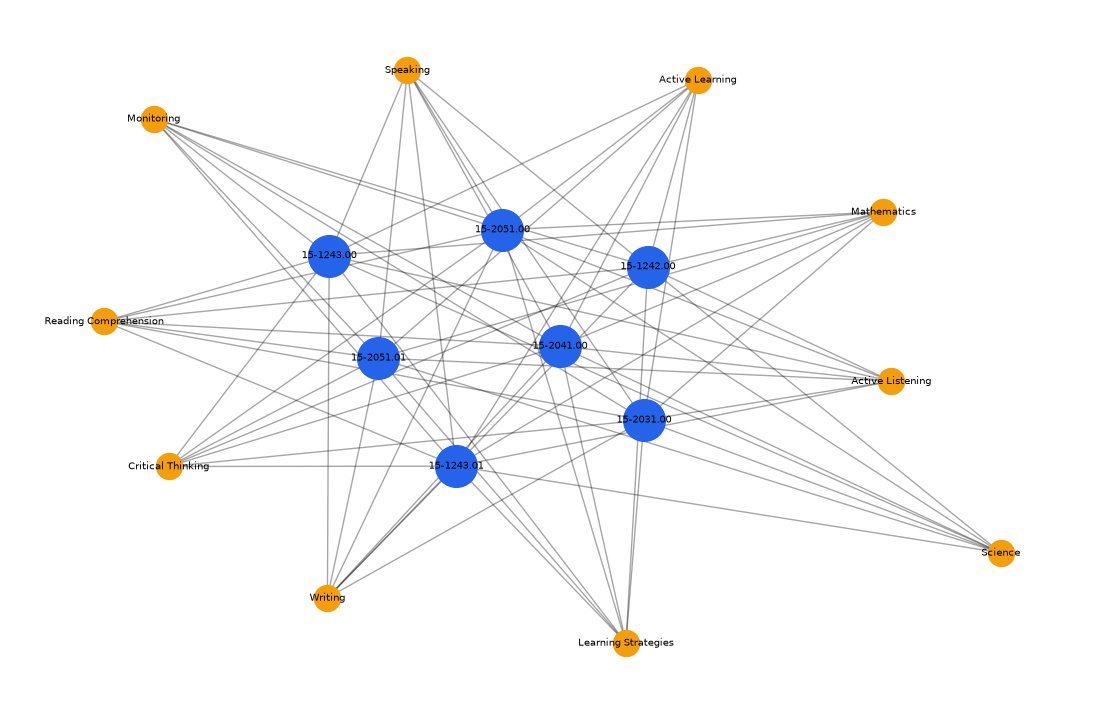

In [14]:
domain = 'essential_skills'
matrix = main_matrices[domain]
G = nx.Graph()
selected = [x for x in CONFIG['core'] if x in matrix.index]
for code in selected:
    G.add_node(code, kind='occupation', label=names.get(code, code))
    for element, weight in matrix.loc[code].nlargest(10).items():
        node = 'competency:' + element
        G.add_node(node, kind='competency', label=names.get(element, element))
        G.add_edge(code, node, weight=float(weight))
pos = nx.spring_layout(G, seed=42, k=1.4)
plt.figure(figsize=(14, 9))
nx.draw_networkx_nodes(G, pos, nodelist=selected, node_color='#2563eb', node_size=900)
comp_nodes = [n for n in G if n not in selected]
nx.draw_networkx_nodes(G, pos, nodelist=comp_nodes, node_color='#f59e0b', node_size=350)
nx.draw_networkx_edges(G, pos, alpha=.35)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['label'] for n in G}, font_size=7)
plt.axis('off'); plt.show()

## 14. Kesimpulan cara membaca pilot

Kamu mengambil rating Importance dari O*NET, memastikan datanya cukup lengkap, mengubahnya menjadi profil kompetensi, lalu mengukur kemiripan dengan dua cara.

- Embedding membandingkan makna teks kompetensi.
- Graph membandingkan kompetensi dan bobot yang sama.
- Hasil per domain lebih penting daripada satu skor gabungan.
- Occupation fokus hanya membantu interpretasi; perhitungan utama memakai seluruh occupation complete-case.
- Semua hasil adalah deskriptif untuk konteks pekerjaan Amerika Serikat, bukan prediksi individu atau klaim tentang pasar kerja Indonesia.

## 15. Uji sensitivitas pairwise-complete (opsional)

Cell berikut sengaja tidak otomatis dijalankan karena lebih lama. Jika ingin melihatnya, ubah `RUN_PAIRWISE` menjadi `True`. Ia membandingkan pasangan berdasarkan elemen valid yang sama-sama tersedia dan menyimpan jumlah elemen bersama serta rasio coverage.

In [15]:
RUN_PAIRWISE = False
if RUN_PAIRWISE:
    pairwise_results = {}
    for domain, matrix in all_matrices.items():
        pairwise_results[('graph', domain)] = similarity(matrix, 'graph')
        pairwise_results[('embedding', domain)] = embedding_similarity(matrix, texts, model)
    display(Markdown('Pairwise-complete selesai. Periksa n_common_elements dan coverage_ratio dari tuple hasil.'))
else:
    display(Markdown('Mode pairwise-complete belum dijalankan. Ubah RUN_PAIRWISE = True jika diperlukan.'))

Mode pairwise-complete belum dijalankan. Ubah RUN_PAIRWISE = True jika diperlukan.